In [1]:
%load_ext line_profiler

In [2]:
from rabtracks import *
sns.set_context("paper")
BASINS = ['NA', 'EP', 'NI', 'SI', 'SP', 'WP']

In [3]:
data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}

/tmp/ipykernel_688/2144106322.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}
/tmp/ipykernel_688/2144106322.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}


In [4]:
data_df = {b: {s: data[b].sel(source = s).to_dataframe() for s in data[b].source.values} for b in BASINS}

## Yearly Hit Rates

In [5]:
def compute_HR_yearly(b, s, year):
    d = data_df[b][s]
    d = d[d.season == year]
    if d.track_id.nunique() > 0:
        return 1 - d.groupby("track_id").lon.max().isna().sum() / d.track_id.nunique()
    else:
        return np.nan

In [6]:
df = pd.DataFrame([
    {
        "basin": b,
        "source": s,
        "HR": compute_HR_yearly(b, s, y),
        "season": y,
    }
    for b in BASINS
    for s in data[b].source.values
    for y in range(1940, 2025)
])
df = df[df.source != "IBTrACS"]

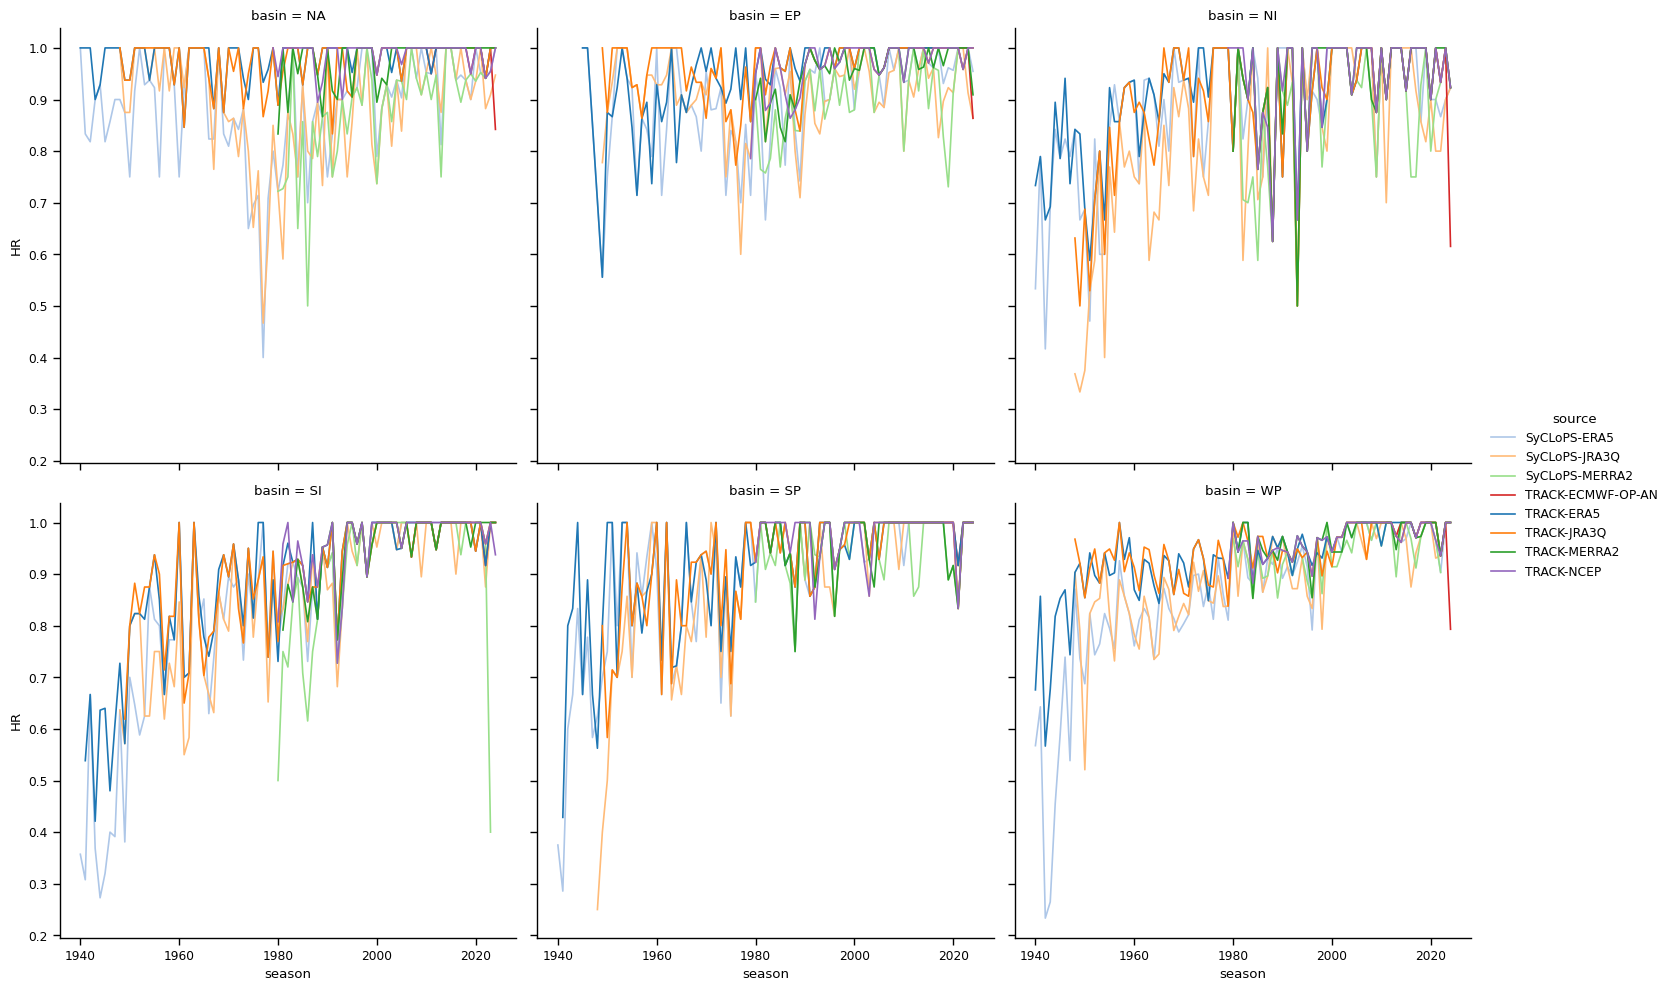

In [7]:
sns.relplot(data = df[df.HR > 0.2], col = "basin", col_wrap = 3, hue = "source", x = "season", y = "HR", kind = "line", palette = PALETTE)

## Overall Hit Rate for a given period

In [8]:
def compute_HR_period(b, s, yearmin, yearmax):
    d = data_df[b][s]
    d = d[d.season.between(yearmin, yearmax)]
    if d.track_id.nunique() > 0:
        return 1 - d.groupby("track_id").lon.max().isna().sum() / d.track_id.nunique()
    else:
        return np.nan

In [9]:
df = pd.DataFrame([
    {
        "basin": b,
        "source": s,
        "HR": compute_HR_period(b, s, 2006,2022)*100,
    }
    for b in BASINS
    for s in data[b].source.values
])
df = df[df.source != "IBTrACS"]
df_base = df.copy()

## Compute only for intense cyclones

In [10]:
def compute_HR_period_intense(b, s, yearmin, yearmax, wind_threshold):
    d = data_df[b][s]
    ib = data_df[b]["IBTrACS"]
    tids = ib[ib.wmo_wind >= wind_threshold].track_id
    d = d[(d.season.between(yearmin, yearmax)) & (d.track_id.isin(tids))]
    if d.track_id.nunique() > 0:
        return 1 - d.groupby("track_id").lon.max().isna().sum() / d.track_id.nunique()
    else:
        return np.nan

In [11]:
df = pd.DataFrame([
    {
        "basin": b,
        "source": s,
        "HR": compute_HR_period_intense(b, s, 2006,2022, 32)*100,
    }
    for b in BASINS
    for s in data[b].source.values
])
df = df[df.source != "IBTrACS"]
df_intense = df.copy()

In [12]:
df = df_base.merge(df_intense, on = ["basin", "source"], suffixes = ["", "_intense"])

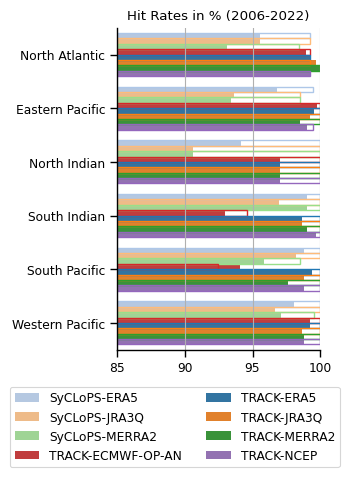

In [28]:
basin_names = {
    "NA": "North Atlantic",
    "EP": "Eastern Pacific",
    "WP": "Western Pacific",
    "NI": "North Indian",
    "SI": "South Indian",
    "SP": "South Pacific",
    "SA": "South Atlantic",
}
df["basin_full"] = df["basin"].map(basin_names)

fig = plt.figure(figsize=cm2inch([9, 10]))
ax = sns.barplot(data=df,
                 y="basin_full", hue="source", x="HR",
                 palette=PALETTE, orient="h")
ax = sns.barplot(data=df,
                 y="basin_full", hue="source", x="HR_intense",
                 palette=PALETTE, orient="h", fill = False, linewidth = 1, legend = False)
plt.title("Hit Rates in % (2006-2022)")
plt.xlim(85, 100)
plt.grid(axis='x')
ax.get_legend().remove()
fig.legend(ncol=2, loc="outside upper center",
           bbox_to_anchor=(0.5, 0.02), frameon=True)
plt.ylabel("")
plt.xlabel("")
sns.despine()
plt.tight_layout()

plt.savefig("hit_rates.png", bbox_inches="tight")
plt.savefig("hit_rates.pdf", bbox_inches="tight")

In [18]:
df.describe()

,HR,HR_intense
count,48.000000,48.000000
mean,97.378027,99.472228
std,2.405183,1.362814
min,90.588235,92.424242
25%,96.787677,99.424362
50%,98.584242,100.000000
75%,99.000468,100.000000
max,100.000000,100.000000


In [27]:
df.sort_values("HR_intense")

,basin,source,HR,HR_intense,basin_full
35,SP,TRACK-ECMWF-OP-AN,94.082840,92.424242,South Pacific
27,SI,TRACK-ECMWF-OP-AN,92.953020,94.573643,South Indian
2,NA,SyCLoPS-MERRA2,93.150685,98.425197,North Atlantic
10,EP,SyCLoPS-MERRA2,93.398533,98.484848,Eastern Pacific
34,SP,SyCLoPS-MERRA2,95.857988,98.484848,South Pacific
9,EP,SyCLoPS-JRA3Q,93.643032,98.484848,Eastern Pacific
4,NA,TRACK-ERA5,99.315068,99.212598,North Atlantic
5,NA,TRACK-JRA3Q,99.657534,99.212598,North Atlantic
7,NA,TRACK-NCEP,99.315068,99.212598,North Atlantic
3,NA,TRACK-ECMWF-OP-AN,98.972603,99.212598,North Atlantic


In [21]:
df.groupby("source").HR.mean()

source
SyCLoPS-ERA5         97.057941
SyCLoPS-JRA3Q        95.278348
SyCLoPS-MERRA2       94.844126
TRACK-ECMWF-OP-AN    97.007177
TRACK-ERA5           98.861862
TRACK-JRA3Q          98.682104
TRACK-MERRA2         98.508111
TRACK-NCEP           98.784551
Name: HR, dtype: float64

In [25]:
df[df.source.isin(["TRACK-ERA5", "TRACK-JRA3Q", "TRACK-MERRA2"])].HR.mean()

np.float64(98.68402553429688)

In [26]:
df[df.source.isin(["SyCLoPS-ERA5", "SyCLoPS-JRA3Q", "SyCLoPS-MERRA2"])].HR.mean()

np.float64(95.72680502268005)